# Task 3: GNN–BERT Fusion for Multi-Context

In [1]:
!pip install -q librosa torch_geometric transformers scikit-learn matplotlib pandas tqdm

import os, ast as py_ast, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.6 MB/s eta 0:00:00
Using device: cuda


## AUC-PR helper

In [2]:
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

def macro_auc_pr(y_true, y_probs, num_classes):
    """Mean one-vs-rest AUC-PR across classes, from softmax probabilities.

    y_true:  1D array of int class labels, shape [N]
    y_probs: 2D array of predicted probabilities, shape [N, num_classes]
    """
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    return average_precision_score(y_true_bin, y_probs, average="macro")

## 1. Reproduce the FMA-small sample (identical to Task 2)

In [3]:
if not os.path.exists('fma_metadata'):
    !wget -q https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
    !unzip -q fma_metadata.zip
    print("Metadata downloaded.")

tracks = pd.read_csv('fma_metadata/tracks.csv', index_col=0, header=[0, 1])
subset = tracks[tracks['set', 'subset'] == 'small'].copy()
subset = subset.dropna(subset=[('track', 'genre_top')])
print(f"Tracks with a top genre label: {len(subset)}")

N_TRACKS = 2000

sampled = (
    subset.groupby(('track', 'genre_top'), group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_TRACKS // 8), random_state=SEED))
)
print(f"Sampled tracks: {len(sampled)}")

genre_list = sorted(sampled['track', 'genre_top'].unique())
genre_to_idx = {g: i for i, g in enumerate(genre_list)}
print(genre_to_idx)


Metadata downloaded.
Tracks with a top genre label: 8000
Sampled tracks: 2000
{'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}


/tmp/ipykernel_559/1842470290.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_TRACKS // 8), random_state=SEED))


In [4]:
def track_id_to_path(track_id):
    tid_str = f"{track_id:06d}"
    return f"fma_small/{tid_str[:3]}/{tid_str}.mp3"

sampled_ids = sampled.index.tolist()

if not os.path.exists('audio_subset') or len(os.listdir('audio_subset')) == 0:
    if not os.path.exists('fma_small.zip'):
        !wget -q --show-progress https://os.unil.cloud.switch.ch/fma/fma_small.zip
    import zipfile
    wanted_paths = {track_id_to_path(tid) for tid in sampled_ids}
    os.makedirs('audio_subset', exist_ok=True)
    extracted, missing = 0, 0
    with zipfile.ZipFile('fma_small.zip', 'r') as z:
        all_names = set(z.namelist())
        for tid in sampled_ids:
            p = track_id_to_path(tid)
            if p in all_names:
                z.extract(p, 'audio_subset')
                extracted += 1
            else:
                missing += 1
    print(f"Extracted: {extracted} | Missing: {missing}")
    if os.path.exists('fma_small.zip'):
        os.remove('fma_small.zip')
else:
    print("audio_subset already present, skipping download.")


fma_small.zip       100%[===================>]   7.15G  21.9MB/s    in 5m 47s  
Extracted: 2000 | Missing: 0


## 2. Build per-track hint text (Xtext) from FMA metadata

In [5]:
def build_hint_text(track_id):
    row = sampled.loc[track_id]
    genre = row[('track', 'genre_top')]
    text = "music clip"
    try:
        tags_raw = row[('track', 'tags')]
        tags = py_ast.literal_eval(tags_raw) if isinstance(tags_raw, str) else tags_raw
        if tags:
            text += "; tags: " + ", ".join(tags[:8])
    except (KeyError, ValueError, SyntaxError, TypeError):
        pass
    return text

hint_texts = {tid: build_hint_text(tid) for tid in sampled_ids}
# Peek at a few examples
for tid in sampled_ids[:5]:
    print(tid, "->", hint_texts[tid])


93521 -> music clip; tags: ambient, chillstep, synth wave, electronica
115811 -> music clip
115814 -> music clip
110106 -> music clip; tags: chiptune, 8bit
79606 -> music clip


## 3. Segment graphs + GraphSAGE encoder (identical to Task 2)

In [6]:
import librosa
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

SR = 22050
SEGMENT_SEC = 5
TAU = 0.85

def build_segment_graph_with_id(mp3_path, genre_idx, track_id):
    g = build_segment_graph_core(mp3_path, genre_idx)
    if g is not None:
        g.track_id = track_id
    return g

def build_segment_graph_core(mp3_path, genre_idx):
    y, sr = librosa.load(mp3_path, sr=SR, duration=30)
    if len(y) < SR:
        return None
    seg_len = SEGMENT_SEC * SR
    n_segments = max(1, len(y) // seg_len)
    node_feats = []
    for i in range(n_segments):
        chunk = y[i * seg_len: (i + 1) * seg_len]
        if len(chunk) < seg_len // 2:
            continue
        chroma = librosa.feature.chroma_stft(y=chunk, sr=sr).mean(axis=1)   # 12-dim
        mfcc = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=20).mean(axis=1)  # 20-dim
        node_feats.append(np.concatenate([chroma, mfcc]))                    # 32-dim
    if len(node_feats) < 2:
        return None
    x = torch.tensor(np.stack(node_feats), dtype=torch.float32)
    n = x.shape[0]
    edges = set()
    for i in range(n - 1):
        edges.add((i, i + 1)); edges.add((i + 1, i))
    norm_x = x / (x.norm(dim=1, keepdim=True) + 1e-8)
    sim = norm_x @ norm_x.T
    for i in range(n):
        for j in range(n):
            if i != j and sim[i, j] > TAU:
                edges.add((i, j))
    edge_index = torch.tensor(list(edges), dtype=torch.long).T if edges else torch.empty((2, 0), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=torch.tensor([genre_idx], dtype=torch.long))

from tqdm import tqdm

graphs = []
skipped = 0
for tid in tqdm(sampled_ids):
    path = os.path.join('audio_subset', track_id_to_path(tid))
    if not os.path.exists(path):
        skipped += 1
        continue
    genre = sampled.loc[tid, ('track', 'genre_top')]
    g = build_segment_graph_with_id(path, genre_to_idx[genre], tid)
    if g is not None:
        graphs.append(g)
    else:
        skipped += 1

print(f"Graphs built: {len(graphs)} | Skipped: {skipped}")


  4%|▎         | 72/2000 [00:34<07:52,  4.08it/s]/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 49%|████▉     | 983/2000 [04:49<04:12,  4.02it/s]/tmp/ipykernel_559/3676417209.py:22: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=SR, duration=30)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 51%|█████▏    | 1025/2000 [05:00<06:54,  2.35it/s]/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 2000/2000 [09:30<00:00,  3.51it/s]

Graphs built: 1999 | Skipped: 1


In [7]:
class GraphSAGEClassifier(nn.Module):
    """Identical architecture to Task 2, extended to optionally return the
    pooled graph embedding g (pre-classifier) instead of / alongside logits."""

    def __init__(self, in_dim=12, hidden_dim=64, num_classes=8, num_layers=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch, return_embedding=False):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        g = global_mean_pool(x, batch)  # mean readout, per Algorithm 2
        logits = self.classifier(g)
        if return_embedding:
            return logits, g
        return logits


In [8]:
# --- GNN checkpoint + split: must be IDENTICAL to Task 2, no fallback ------
from sklearn.metrics import f1_score, accuracy_score

GNN_CHECKPOINT_PATH = "task2_gnn_graphsage.pt"
SPLIT_PATH = "task2_split_track_ids.json"

assert os.path.exists(GNN_CHECKPOINT_PATH), (
    f"{GNN_CHECKPOINT_PATH} not found — copy it from Task 2 first. "
    "Do not proceed with a freshly retrained GNN; results won't be comparable."
)
assert os.path.exists(SPLIT_PATH), (
    f"{SPLIT_PATH} not found — copy it from Task 2 so Task 3 reuses the identical split."
)

with open(SPLIT_PATH) as f:
    split_ids = json.load(f)
train_ids = set(split_ids["train"])
val_ids   = set(split_ids["val"])
test_ids  = set(split_ids["test"])

by_id = {int(g.track_id): g for g in graphs}
missing = (train_ids | val_ids | test_ids) - set(by_id.keys())
if missing:
    print(f"Warning: {len(missing)} track(s) from Task 2's split failed to "
          f"rebuild in this run and will be dropped: {sorted(missing)[:5]}...")

train_graphs = [by_id[i] for i in train_ids if i in by_id]
val_graphs   = [by_id[i] for i in val_ids   if i in by_id]
test_graphs  = [by_id[i] for i in test_ids  if i in by_id]
print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

train_loader = GeoDataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = GeoDataLoader(val_graphs, batch_size=32)
test_loader  = GeoDataLoader(test_graphs, batch_size=32)

gnn_model = GraphSAGEClassifier(in_dim=32, num_classes=len(genre_list)).to(device)
gnn_model.load_state_dict(torch.load(GNN_CHECKPOINT_PATH, map_location=device))
gnn_model.eval()
print(f"Loaded Task 2's exact GNN checkpoint from {GNN_CHECKPOINT_PATH}")

def evaluate_gnn(loader):
    gnn_model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = gnn_model(batch.x, batch.edge_index, batch.batch)
            probs.append(F.softmax(out, dim=1).cpu())
            preds.append(out.argmax(dim=1).cpu())
            labels.append(batch.y.cpu())
    preds = torch.cat(preds).numpy(); labels = torch.cat(labels).numpy(); probs = torch.cat(probs).numpy()
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    auc_pr = macro_auc_pr(labels, probs, num_classes=len(genre_list))
    return acc, f1, auc_pr

test_acc_gnn, test_f1_gnn, test_auc_pr_gnn = evaluate_gnn(test_loader)
print(f"GNN-only Test Accuracy: {test_acc_gnn:.4f} | Macro-F1: {test_f1_gnn:.4f} | AUC-PR: {test_auc_pr_gnn:.4f}")

Train: 1398 | Val: 300 | Test: 300
Loaded Task 2's exact GNN checkpoint from task2_gnn_graphsage.pt
GNN-only Test Accuracy: 0.3733 | Macro-F1: 0.3580 | AUC-PR: 0.3861


## 4. BERT text encoder for FMA hint text

In [9]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "distilbert-base-uncased"
FUSION_DIM = 128
TEXT_MAX_LEN = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class BertTextEncoder(nn.Module):
    def __init__(self, model_name=MODEL_NAME, out_dim=FUSION_DIM,
                 task1_checkpoint="task1_bert_tag_classifier.pt"):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.proj = nn.Linear(hidden, out_dim)
        if os.path.exists(task1_checkpoint):
            state = torch.load(task1_checkpoint, map_location="cpu")
            bert_state = {k[len("bert."):]: v for k, v in state.items() if k.startswith("bert.")}
            missing, unexpected = self.bert.load_state_dict(bert_state, strict=False)
            print(f"Warm-started from {task1_checkpoint} "
                  f"({len(bert_state)} tensors; missing={len(missing)}, unexpected={len(unexpected)})")
        else:
            print(f"{task1_checkpoint} not found — using vanilla pretrained {model_name}.")

    def forward(self, texts):
        enc = tokenizer(texts, truncation=True, padding=True, max_length=TEXT_MAX_LEN, return_tensors="pt")
        enc = {k: v.to(next(self.parameters()).device) for k, v in enc.items()}
        out = self.bert(**enc)
        token_embeddings = out.last_hidden_state
        cls = token_embeddings[:, 0, :]
        cls_proj = self.proj(cls)
        return token_embeddings, cls_proj, enc["attention_mask"]

bert_encoder_fusion    = BertTextEncoder().to(device)
bert_encoder_text_only = BertTextEncoder().to(device)
bert_encoder_concat    = BertTextEncoder().to(device)

_tok, _cls, _mask = bert_encoder_fusion([hint_texts[sampled_ids[0]], hint_texts[sampled_ids[1]]])
print("token_embeddings:", _tok.shape, "| cls_proj:", _cls.shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


task1_bert_tag_classifier.pt not found — using vanilla pretrained distilbert-base-uncased.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


task1_bert_tag_classifier.pt not found — using vanilla pretrained distilbert-base-uncased.
token_embeddings: torch.Size([2, 18, 768]) | cls_proj: torch.Size([2, 128])


## 5. Cross-attention fusion model (Algorithm 3)

In [10]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, graph_dim=64, text_dim=768, fusion_dim=FUSION_DIM, num_classes=8):
        super().__init__()
        self.graph_proj = nn.Linear(graph_dim, fusion_dim)
        self.q_proj = nn.Linear(fusion_dim, fusion_dim)
        self.k_proj = nn.Linear(text_dim, fusion_dim)
        self.v_proj = nn.Linear(text_dim, fusion_dim)
        self.classifier = nn.Linear(fusion_dim * 2, num_classes)
        self.scale = fusion_dim ** 0.5

    def forward(self, g_raw, token_embeddings, attention_mask):
        g = self.graph_proj(g_raw)                          # [B, fusion_dim]
        Q = self.q_proj(g).unsqueeze(1)                      # [B, 1, fusion_dim]
        K = self.k_proj(token_embeddings)                    # [B, L, fusion_dim]
        V = self.v_proj(token_embeddings)                    # [B, L, fusion_dim]

        scores = (Q @ K.transpose(-2, -1)) / self.scale       # [B, 1, L]
        mask = attention_mask.unsqueeze(1).bool()             # [B, 1, L]
        scores = scores.masked_fill(~mask, float("-inf"))
        attn = torch.softmax(scores, dim=-1)                  # [B, 1, L]
        attended_text = (attn @ V).squeeze(1)                 # [B, fusion_dim]

        z = torch.cat([g, attended_text], dim=-1)             # [B, 2*fusion_dim]
        logits = self.classifier(z)
        return logits, z, attn.squeeze(1)


class EarlyConcatFusion(nn.Module):
    """Ablation: same inputs, no attention — just concat g and CLS."""
    def __init__(self, graph_dim=64, text_dim=FUSION_DIM, num_classes=8):
        super().__init__()
        self.graph_proj = nn.Linear(graph_dim, FUSION_DIM)
        self.classifier = nn.Linear(FUSION_DIM + text_dim, num_classes)

    def forward(self, g_raw, cls_proj):
        g = self.graph_proj(g_raw)
        z = torch.cat([g, cls_proj], dim=-1)
        return self.classifier(z), z


class TextOnlyClassifier(nn.Module):
    """Ablation: BERT-only, no graph."""
    def __init__(self, text_dim=FUSION_DIM, num_classes=8):
        super().__init__()
        self.classifier = nn.Linear(text_dim, num_classes)

    def forward(self, cls_proj):
        return self.classifier(cls_proj)


## 6. Fusion dataset — pairs each graph with its track's hint text

In [11]:
def graphs_to_dataset(graph_list):
    items = []
    for g in graph_list:
        tid = int(g.track_id)
        items.append({"graph": g, "text": hint_texts[tid], "label": int(g.y.item()), "track_id": tid})
    return items

train_items = graphs_to_dataset(train_graphs)
val_items = graphs_to_dataset(val_graphs)
test_items = graphs_to_dataset(test_graphs)

def make_batches(items, batch_size=32, shuffle=False):
    idx = list(range(len(items)))
    if shuffle:
        random.shuffle(idx)
    for i in range(0, len(idx), batch_size):
        batch_idx = idx[i:i + batch_size]
        yield [items[j] for j in batch_idx]

def get_graph_embeddings(batch_items):
    """Runs the (frozen) GNN encoder over a batch of graphs, returns [B, 64]."""
    geo_batch = GeoDataLoader([it["graph"] for it in batch_items], batch_size=len(batch_items))
    geo_batch = next(iter(geo_batch)).to(device)
    with torch.no_grad():
        _, g_emb = gnn_model(geo_batch.x, geo_batch.edge_index, geo_batch.batch, return_embedding=True)
    return g_emb


## 7. Train the full cross-attention fusion model

In [12]:
from sklearn.metrics import f1_score, accuracy_score

fusion_model = CrossAttentionFusion(graph_dim=gnn_model.hidden_dim, text_dim=768, num_classes=len(genre_list)).to(device)
optimizer = torch.optim.AdamW(list(fusion_model.parameters()) + list(bert_encoder_fusion.parameters()), lr=2e-5)
criterion = nn.CrossEntropyLoss()

def run_fusion_epoch(items, train=True, batch_size=32, collect_probs=False):
    fusion_model.train(train)
    bert_encoder_fusion.train(train)
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for batch_items in make_batches(items, batch_size=batch_size, shuffle=train):
        labels = torch.tensor([it["label"] for it in batch_items], dtype=torch.long).to(device)
        texts = [it["text"] for it in batch_items]
        g_emb = get_graph_embeddings(batch_items)  # [B, 64], frozen GNN
        token_emb, cls_proj, mask = bert_encoder_fusion(texts)

        if train:
            optimizer.zero_grad()
            logits, z, _ = fusion_model(g_emb, token_emb, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits, z, _ = fusion_model(g_emb, token_emb, mask)
                loss = criterion(logits, labels)

        total_loss += loss.item() * len(batch_items)
        all_preds.append(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        if collect_probs:
            all_probs.append(F.softmax(logits, dim=1).detach().cpu().numpy())

    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    if collect_probs:
        all_probs = np.concatenate(all_probs)
        auc_pr = macro_auc_pr(all_labels, all_probs, num_classes=len(genre_list))
        return total_loss / len(items), acc, f1, auc_pr
    return total_loss / len(items), acc, f1

FUSION_EPOCHS = 8
fusion_history = {"train_loss": [], "val_acc": [], "val_f1": []}
for epoch in range(FUSION_EPOCHS):
    train_loss, train_acc, train_f1 = run_fusion_epoch(train_items, train=True)
    _, val_acc, val_f1 = run_fusion_epoch(val_items, train=False)
    fusion_history["train_loss"].append(train_loss)
    fusion_history["val_acc"].append(val_acc)
    fusion_history["val_f1"].append(val_f1)
    print(f"Epoch {epoch+1}/{FUSION_EPOCHS} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

test_loss, test_acc_fusion, test_f1_fusion, test_auc_pr_fusion = run_fusion_epoch(test_items, train=False, collect_probs=True)
print(f"\nFull Fusion Test Accuracy: {test_acc_fusion:.4f} | Macro-F1: {test_f1_fusion:.4f} | AUC-PR: {test_auc_pr_fusion:.4f}")


Epoch 1/8 | loss=2.1101 | train_acc=0.1423 | val_acc=0.2333 | val_f1=0.2250
Epoch 2/8 | loss=1.9082 | train_acc=0.2883 | val_acc=0.2900 | val_f1=0.2696
Epoch 3/8 | loss=1.7157 | train_acc=0.3863 | val_acc=0.3500 | val_f1=0.3327
Epoch 4/8 | loss=1.5439 | train_acc=0.4485 | val_acc=0.3867 | val_f1=0.3841
Epoch 5/8 | loss=1.4309 | train_acc=0.4979 | val_acc=0.4033 | val_f1=0.3950
Epoch 6/8 | loss=1.3614 | train_acc=0.5114 | val_acc=0.4000 | val_f1=0.3938
Epoch 7/8 | loss=1.3129 | train_acc=0.5243 | val_acc=0.4133 | val_f1=0.4067
Epoch 8/8 | loss=1.2794 | train_acc=0.5379 | val_acc=0.4633 | val_f1=0.4608

Full Fusion Test Accuracy: 0.4467 | Macro-F1: 0.4329 | AUC-PR: 0.4720


## 8. Ablations — BERT-only, GNN-only, early-concat, full fusion

In [13]:
# --- BERT-only ---------------------------------------------------------
text_only_model = TextOnlyClassifier(num_classes=len(genre_list)).to(device)
to_optimizer = torch.optim.AdamW(list(text_only_model.parameters()) + list(bert_encoder_text_only.parameters()), lr=2e-5)

def run_text_only_epoch(items, train=True, batch_size=32, collect_probs=False):
    text_only_model.train(train); bert_encoder_text_only.train(train)
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for batch_items in make_batches(items, batch_size=batch_size, shuffle=train):
        labels = torch.tensor([it["label"] for it in batch_items], dtype=torch.long).to(device)
        texts = [it["text"] for it in batch_items]
        _, cls_proj, _ = bert_encoder_text_only(texts)
        if train:
            to_optimizer.zero_grad()
            logits = text_only_model(cls_proj)
            loss = criterion(logits, labels)
            loss.backward(); to_optimizer.step()
        else:
            with torch.no_grad():
                logits = text_only_model(cls_proj)
                loss = criterion(logits, labels)
        total_loss += loss.item() * len(batch_items)
        all_preds.append(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        if collect_probs:
            all_probs.append(F.softmax(logits, dim=1).detach().cpu().numpy())
    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    if collect_probs:
        all_probs = np.concatenate(all_probs)
        auc_pr = macro_auc_pr(all_labels, all_probs, num_classes=len(genre_list))
        return total_loss / len(items), acc, f1, auc_pr
    return total_loss / len(items), acc, f1

for epoch in range(5):
    run_text_only_epoch(train_items, train=True)
_, test_acc_text, test_f1_text, test_auc_pr_text = run_text_only_epoch(test_items, train=False, collect_probs=True)
print(f"BERT-only Test Accuracy: {test_acc_text:.4f} | Macro-F1: {test_f1_text:.4f} | AUC-PR: {test_auc_pr_text:.4f}")

# --- Early-concat --------------------------------------------------------
concat_model = EarlyConcatFusion(graph_dim=gnn_model.hidden_dim, num_classes=len(genre_list)).to(device)
concat_optimizer = torch.optim.AdamW(concat_model.parameters(), lr=1e-3)

def run_concat_epoch(items, train=True, batch_size=32, collect_probs=False):
    concat_model.train(train)
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for batch_items in make_batches(items, batch_size=batch_size, shuffle=train):
        labels = torch.tensor([it["label"] for it in batch_items], dtype=torch.long).to(device)
        texts = [it["text"] for it in batch_items]
        g_emb = get_graph_embeddings(batch_items)
        with torch.no_grad():
            _, cls_proj, _ = bert_encoder_concat(texts)  # frozen encoder for this ablation
        if train:
            concat_optimizer.zero_grad()
            logits, _ = concat_model(g_emb, cls_proj)
            loss = criterion(logits, labels)
            loss.backward(); concat_optimizer.step()
        else:
            with torch.no_grad():
                logits, _ = concat_model(g_emb, cls_proj)
                loss = criterion(logits, labels)
        total_loss += loss.item() * len(batch_items)
        all_preds.append(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        if collect_probs:
            all_probs.append(F.softmax(logits, dim=1).detach().cpu().numpy())
    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    if collect_probs:
        all_probs = np.concatenate(all_probs)
        auc_pr = macro_auc_pr(all_labels, all_probs, num_classes=len(genre_list))
        return total_loss / len(items), acc, f1, auc_pr
    return total_loss / len(items), acc, f1

for epoch in range(8):
    run_concat_epoch(train_items, train=True)
_, test_acc_concat, test_f1_concat, test_auc_pr_concat = run_concat_epoch(test_items, train=False, collect_probs=True)
print(f"Early-Concat Test Accuracy: {test_acc_concat:.4f} | Macro-F1: {test_f1_concat:.4f} | AUC-PR: {test_auc_pr_concat:.4f}")


BERT-only Test Accuracy: 0.2100 | Macro-F1: 0.2130 | AUC-PR: 0.2709
Early-Concat Test Accuracy: 0.3733 | Macro-F1: 0.3699 | AUC-PR: 0.3780


In [14]:
comparison = pd.DataFrame([
    {"Model": "GNN-only (Task 2)",      "Accuracy": test_acc_gnn,    "Macro-F1": test_f1_gnn,    "AUC-PR": test_auc_pr_gnn},
    {"Model": "BERT-only",              "Accuracy": test_acc_text,   "Macro-F1": test_f1_text,   "AUC-PR": test_auc_pr_text},
    {"Model": "Early-Concat",           "Accuracy": test_acc_concat, "Macro-F1": test_f1_concat, "AUC-PR": test_auc_pr_concat},
    {"Model": "Cross-Attention Fusion", "Accuracy": test_acc_fusion, "Macro-F1": test_f1_fusion, "AUC-PR": test_auc_pr_fusion},
])
print(comparison.to_string(index=False))

os.makedirs("results", exist_ok=True)
comparison.to_csv("results/task3_ablation_comparison.csv", index=False)

                 Model  Accuracy  Macro-F1   AUC-PR
     GNN-only (Task 2)  0.373333  0.358007 0.386060
             BERT-only  0.210000  0.212972 0.270888
          Early-Concat  0.373333  0.369914 0.377986
Cross-Attention Fusion  0.446667  0.432893 0.472049


## Quick AUC-PR recompute (no retraining)

In [16]:
required = ['gnn_model', 'bert_encoder_fusion', 'bert_encoder_text_only',
            'bert_encoder_concat', 'fusion_model', 'text_only_model',
            'concat_model', 'test_items', 'test_loader', 'genre_list']
missing = [v for v in required if v not in globals()]
assert not missing, f"Missing (re-run full pipeline instead): {missing}"

@torch.no_grad()
def eval_probs_gnn(loader):
    gnn_model.eval()
    preds, labels, probs = [], [], []
    for batch in loader:
        batch = batch.to(device)
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        probs.append(F.softmax(out, dim=1).cpu())
        preds.append(out.argmax(dim=1).cpu())
        labels.append(batch.y.cpu())
    return (torch.cat(preds).numpy(), torch.cat(labels).numpy(), torch.cat(probs).numpy())

@torch.no_grad()
def eval_probs_fusion(items, batch_size=32):
    fusion_model.eval(); bert_encoder_fusion.eval()
    preds, labels, probs = [], [], []
    for batch_items in make_batches(items, batch_size=batch_size, shuffle=False):
        lbl = torch.tensor([it["label"] for it in batch_items], dtype=torch.long)
        texts = [it["text"] for it in batch_items]
        g_emb = get_graph_embeddings(batch_items)
        token_emb, cls_proj, mask = bert_encoder_fusion(texts)
        logits, _, _ = fusion_model(g_emb, token_emb, mask)
        preds.append(logits.argmax(dim=1).cpu().numpy())
        labels.append(lbl.numpy())
        probs.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds), np.concatenate(labels), np.concatenate(probs)

@torch.no_grad()
def eval_probs_text_only(items, batch_size=32):
    text_only_model.eval(); bert_encoder_text_only.eval()
    preds, labels, probs = [], [], []
    for batch_items in make_batches(items, batch_size=batch_size, shuffle=False):
        lbl = torch.tensor([it["label"] for it in batch_items], dtype=torch.long)
        texts = [it["text"] for it in batch_items]
        _, cls_proj, _ = bert_encoder_text_only(texts)
        logits = text_only_model(cls_proj)
        preds.append(logits.argmax(dim=1).cpu().numpy())
        labels.append(lbl.numpy())
        probs.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds), np.concatenate(labels), np.concatenate(probs)

@torch.no_grad()
def eval_probs_concat(items, batch_size=32):
    concat_model.eval(); bert_encoder_concat.eval()
    preds, labels, probs = [], [], []
    for batch_items in make_batches(items, batch_size=batch_size, shuffle=False):
        lbl = torch.tensor([it["label"] for it in batch_items], dtype=torch.long)
        texts = [it["text"] for it in batch_items]
        g_emb = get_graph_embeddings(batch_items)
        _, cls_proj, _ = bert_encoder_concat(texts)
        logits, _ = concat_model(g_emb, cls_proj)
        preds.append(logits.argmax(dim=1).cpu().numpy())
        labels.append(lbl.numpy())
        probs.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds), np.concatenate(labels), np.concatenate(probs)

K = len(genre_list)
p, l, pr = eval_probs_gnn(test_loader)
test_acc_gnn, test_f1_gnn = accuracy_score(l, p), f1_score(l, p, average='macro', zero_division=0)
test_auc_pr_gnn = macro_auc_pr(l, pr, K)

p, l, pr = eval_probs_text_only(test_items)
test_acc_text, test_f1_text = accuracy_score(l, p), f1_score(l, p, average='macro', zero_division=0)
test_auc_pr_text = macro_auc_pr(l, pr, K)

p, l, pr = eval_probs_concat(test_items)
test_acc_concat, test_f1_concat = accuracy_score(l, p), f1_score(l, p, average='macro', zero_division=0)
test_auc_pr_concat = macro_auc_pr(l, pr, K)

p, l, pr = eval_probs_fusion(test_items)
test_acc_fusion, test_f1_fusion = accuracy_score(l, p), f1_score(l, p, average='macro', zero_division=0)
test_auc_pr_fusion = macro_auc_pr(l, pr, K)

comparison = pd.DataFrame([
    {"Model": "GNN-only (Task 2)",      "Accuracy": test_acc_gnn,    "Macro-F1": test_f1_gnn,    "AUC-PR": test_auc_pr_gnn},
    {"Model": "BERT-only",              "Accuracy": test_acc_text,   "Macro-F1": test_f1_text,   "AUC-PR": test_auc_pr_text},
    {"Model": "Early-Concat",           "Accuracy": test_acc_concat, "Macro-F1": test_f1_concat, "AUC-PR": test_auc_pr_concat},
    {"Model": "Cross-Attention Fusion", "Accuracy": test_acc_fusion, "Macro-F1": test_f1_fusion, "AUC-PR": test_auc_pr_fusion},
])
print(comparison.to_string(index=False))
comparison.to_csv("results/task3_ablation_comparison.csv", index=False)


                 Model  Accuracy  Macro-F1   AUC-PR
     GNN-only (Task 2)  0.373333  0.358007 0.386060
             BERT-only  0.210000  0.212972 0.270888
          Early-Concat  0.373333  0.369914 0.377986
Cross-Attention Fusion  0.446667  0.432893 0.472049


## 9. t-SNE of fused embeddings + 3 case studies

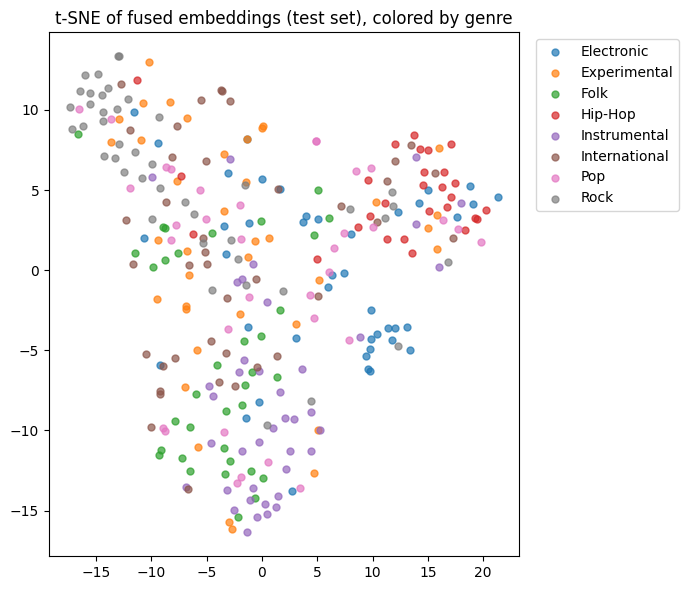

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fusion_model.eval(); bert_encoder_fusion.eval()
all_z, all_labels, all_tids = [], [], []
with torch.no_grad():
    for batch_items in make_batches(test_items, batch_size=32, shuffle=False):
        texts = [it["text"] for it in batch_items]
        g_emb = get_graph_embeddings(batch_items)
        token_emb, _, mask = bert_encoder_fusion(texts)
        _, z, _ = fusion_model(g_emb, token_emb, mask)
        all_z.append(z.cpu().numpy())
        all_labels.extend([it["label"] for it in batch_items])
        all_tids.extend([it["track_id"] for it in batch_items])

all_z = np.concatenate(all_z, axis=0)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(all_z) - 1))
z_2d = tsne.fit_transform(all_z)

plt.figure(figsize=(7, 6))
for idx, genre in enumerate(genre_list):
    mask_g = np.array(all_labels) == idx
    plt.scatter(z_2d[mask_g, 0], z_2d[mask_g, 1], label=genre, alpha=0.7, s=25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("t-SNE of fused embeddings (test set), colored by genre")
plt.tight_layout()
os.makedirs("results/plots", exist_ok=True)
plt.savefig("results/plots/task3_tsne.png", dpi=150)
plt.show()


In [18]:
fusion_model.eval(); bert_encoder_fusion.eval()
case_ids = random.sample(range(len(test_items)), 3)
for i in case_ids:
    item = test_items[i]
    graph = item["graph"]
    with torch.no_grad():
        g_emb = get_graph_embeddings([item])
        token_emb, _, mask = bert_encoder_fusion([item["text"]])
        logits, _, attn = fusion_model(g_emb, token_emb, mask)
        pred = logits.argmax(dim=1).item()

    # Graph path: node/edge counts + a few sample segment transitions
    n_nodes = graph.x.shape[0]
    n_edges = graph.edge_index.shape[1]
    sample_transitions = graph.edge_index.t().tolist()[:6]

    # Caption/lyric alignment: which hint-text tokens the fusion attention
    # weighted most heavily when building the fused embedding
    enc = tokenizer([item["text"]], truncation=True, padding=True,
                     max_length=TEXT_MAX_LEN, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    valid = enc["attention_mask"][0].bool().numpy()
    attn_scores = attn.squeeze(0).cpu().numpy()
    tok_attn = [(tokens[j], float(attn_scores[j])) for j in range(len(tokens))
                if valid[j] and tokens[j] not in ("[CLS]", "[SEP]")]
    tok_attn.sort(key=lambda x: -x[1])
    top_tokens = tok_attn[:3]

    print(f"Track {item['track_id']}")
    print(f"  Graph path: {n_nodes} segment nodes, {n_edges} directed edges "
          f"(sample transitions: {sample_transitions})")
    print(f"  Hint text: {item['text']}")
    print(f"  Top-attended tokens: {top_tokens}")
    print(f"  True genre: {genre_list[item['label']]} | Predicted: {genre_list[pred]}")
    print()


Track 111386
  Graph path: 5 segment nodes, 20 directed edges (sample transitions: [[4, 0], [3, 4], [4, 3], [3, 1], [0, 2], [1, 0]])
  Hint text: music clip
  Top-attended tokens: [('clip', 0.8863978981971741), ('music', 0.04142829030752182)]
  True genre: Pop | Predicted: Hip-Hop

Track 129972
  Graph path: 6 segment nodes, 30 directed edges (sample transitions: [[4, 0], [3, 4], [4, 3], [3, 1], [5, 4], [5, 1]])
  Hint text: music clip
  Top-attended tokens: [('clip', 0.7569571137428284), ('music', 0.09407884627580643)]
  True genre: Rock | Predicted: Hip-Hop

Track 114545
  Graph path: 5 segment nodes, 20 directed edges (sample transitions: [[4, 0], [3, 4], [4, 3], [3, 1], [0, 2], [1, 0]])
  Hint text: music clip; tags: ambient, trip-hop, chillwave, psychedelic, nu-disco, electronic, boom bap, synth
  Top-attended tokens: [('##p', 0.04578706622123718), ('ba', 0.04511766508221626), ('clip', 0.044553492218256)]
  True genre: Electronic | Predicted: Instrumental



In [19]:
# Save the trained fusion model + text encoder for the report/demo notebook
torch.save({
    "fusion_model": fusion_model.state_dict(),
    "bert_encoder":  bert_encoder_fusion.state_dict(),
    "genre_list": genre_list,
}, "task3_fusion_model.pt")

with open("results/metrics.json", "w") as f:
    json.dump(comparison.to_dict(orient="records"), f, indent=2)

print("Saved task3_fusion_model.pt and results/metrics.json")


Saved task3_fusion_model.pt and results/metrics.json
